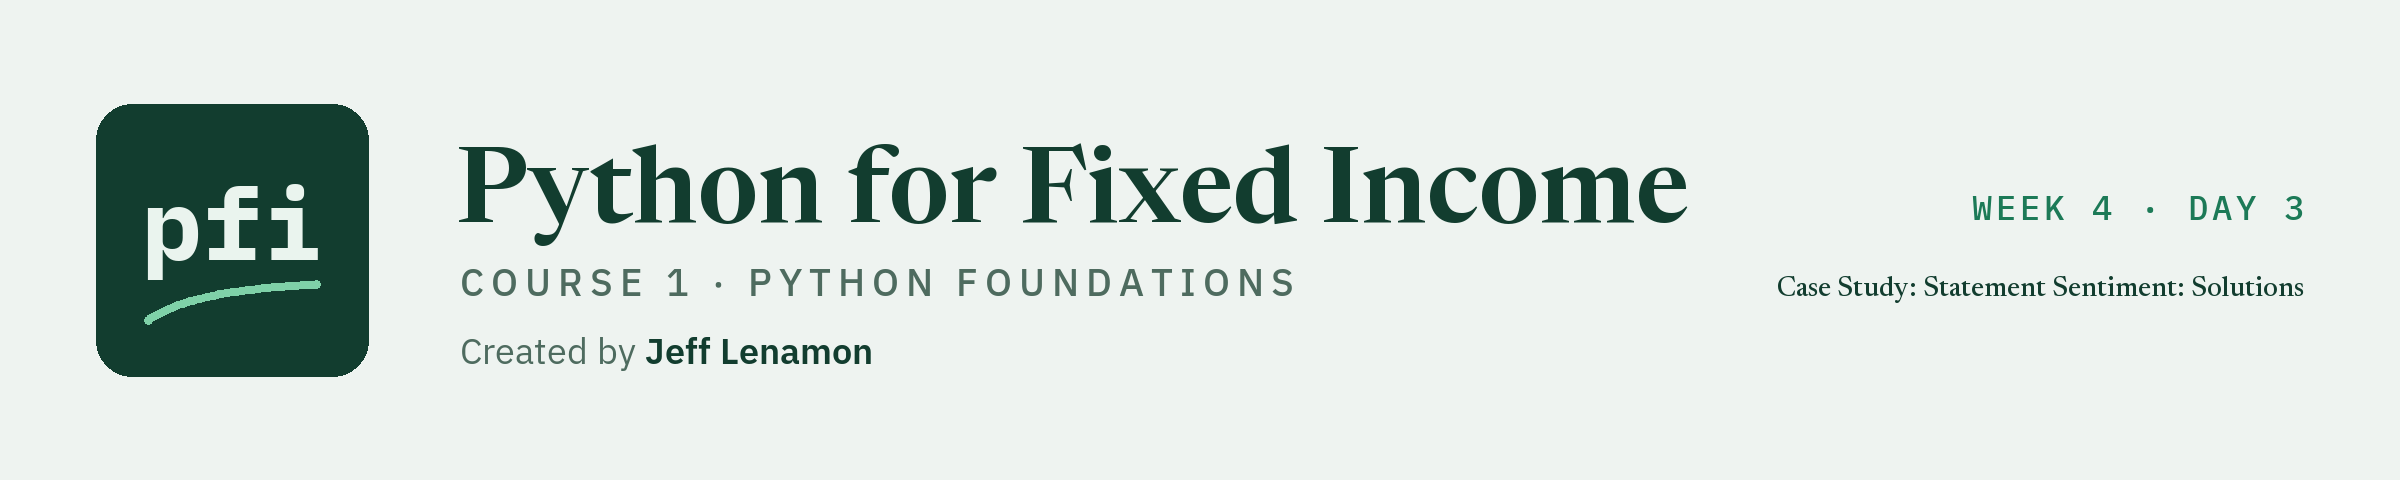

# Case Study: Statement Sentiment - Solutions

Week 4. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day3/18_case_study_statement_sentiment_solutions.ipynb)

### The data

The data is real and public. There is no portfolio data in this notebook.

**The statements**, the file used in notebook 17.

* Source: Board of Governors of the Federal Reserve System, Federal Open Market Committee statements, federalreserve.gov. Each statement was downloaded from its own press release page, which is linked from the calendar page https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. Retrieved on 2026-10-03.
* Reuse: the Board's website says, at https://www.federalreserve.gov/disclaimer.htm, "Unless otherwise indicated, information on Board's website is in the public domain and may be copied and distributed without permission. Please cite to the Board as the source of the information."
* The text in the file is exactly as published. The only change made when the file was built was to white space: one space between words, and one line break between paragraphs.

**The yields**, the file used in notebook 14 and in section 7.0 of the lesson.

* Source: U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates, https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_yield_curve. Retrieved on 2026-10-03, from the yearly CSV downloads on that page.
* Reuse: a work of the United States Government. Treasury's public data inventory, https://www.treasury.gov/jsonfiles/data.json, lists the dataset as public under the CC0 1.0 public domain dedication.
* The figures are as published by Treasury, in percent. Nothing has been filled, smoothed, or removed.

## Exercises

The exercises use the same 46 statements and ask about statements, words, and cuts the lesson did not examine. Exercise 5 asks you to write a function, and the last exercise is the AI check. Every answer is a count or a score from a stated list. None is a reading of what a statement means.

Each exercise below is answered in full, with the words that hit printed, and the check cell after it prints the result.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and defines `clean()`, `remove_stop_words()`, `list_score()`, and `vader_score()` as in the lesson. It creates `analyzer`, types the four word lists, and loads a fresh `statements` with the `kept` and `n_kept` columns. It prints (46, 6) and 10204.

In [1]:
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


def clean(text):
    # lower case, letters only, one space between words, then a list of tokens
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    return re.sub(r'\s+', ' ', text).strip().split(' ')


ready = nltk.download('stopwords', quiet=True)
ready = nltk.download('vader_lexicon', quiet=True)
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

stop_words = stopwords.words('english')
analyzer = SentimentIntensityAnalyzer()


def remove_stop_words(tokens):
    return [token for token in tokens if token not in stop_words]


def list_score(tokens, plus_words, minus_words):
    # hits on the plus list less hits on the minus list, per 100 tokens
    plus = len([token for token in tokens if token in plus_words])
    minus = len([token for token in tokens if token in minus_words])
    return (plus - minus) / len(tokens) * 100


def vader_score(text):
    return analyzer.polarity_scores(text)['compound']


# the three word lists of the lesson
positive_words = ['good', 'strong', 'better', 'gains', 'support', 'progress', 'improved',
                  'improvement', 'confidence', 'growth', 'solid', 'stable', 'recovery', 'benefit']
negative_words = ['bad', 'weak', 'worse', 'risks', 'inflation', 'unemployment', 'pressures',
                  'restrictive', 'uncertain', 'hardship', 'decline', 'loss', 'debt', 'lower']
firm_words = ['expanding', 'expand', 'expanded', 'solid', 'strong', 'robust', 'strengthened',
              'picked', 'resilient', 'gains']
soft_words = ['slowed', 'moderated', 'declined', 'weak', 'weakness', 'weaker', 'softened']

# a fresh copy of the statements. In Colab the file is read from GitHub.
if os.path.exists('../../../data/fomc_statements.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

statements = pd.read_csv(data_folder + 'fomc_statements.csv')
statements['meeting'] = pd.to_datetime(statements['date'], format='%Y-%m-%d')
statements['kept'] = statements['text'].apply(clean).apply(remove_stop_words)
statements['n_kept'] = statements['kept'].str.len()

print(statements.shape, statements['n_kept'].sum())

(46, 6) 10204


### Exercise 1

Q. For the statement dated 2024-03-20, print the tokens that hit the positive list and the tokens that hit the negative list. Store the number of negative hits in **ex1_negative** and the general score per 100 tokens, rounded to 2 decimal places, in **ex1_score**.

In [2]:
# the kept tokens of the statement
tokens = statements.loc[statements['date'] == '2024-03-20', 'kept'].iloc[0]

# the hits on each list, printed so that they can be read
positive_hits = [token for token in tokens if token in positive_words]
negative_hits = [token for token in tokens if token in negative_words]
print('Positive hits:', positive_hits)
print('Negative hits:', negative_hits)
print('Tokens:', len(tokens))

ex1_negative = len(negative_hits)
ex1_score = round(list_score(tokens, positive_words, negative_words), 2)

print('Negative hits:', ex1_negative, ' score per 100 tokens:', ex1_score)

Positive hits: ['solid', 'gains', 'strong', 'better', 'support', 'confidence']
Negative hits: ['unemployment', 'inflation', 'inflation', 'risks', 'inflation', 'uncertain', 'inflation', 'risks', 'risks', 'inflation', 'debt', 'inflation', 'risks', 'inflation', 'pressures', 'inflation']
Tokens: 202
Negative hits: 16  score per 100 tokens: -4.95


* The statement has 6 positive hits and 16 negative hits on 202 tokens. The net is -10, and the general list scores it at -4.95 per 100 tokens.
* 8 of the 16 negative hits are `inflation` and 4 are `risks`.
* The score by hand and `list_score()` agree, which is the check on the function.

In [3]:
check('Exercise 1 negative hits', ex1_negative, 16)
check('Exercise 1 score', ex1_score, -4.95)

Exercise 1 negative hits: correct
Exercise 1 score: correct


### Exercise 2

Q. Take the one word `inflation` off the negative list and score every statement again with the positive list and what is left. How many statements are scored below zero now? Store the answer in **ex2_below**. Which statement has the lowest score, and what is it, rounded to 2 decimal places? Store them in **ex2_date** and **ex2_lowest**.

In [4]:
# the negative list without one word
negative_without = [word for word in negative_words if word != 'inflation']
print('Words left:', len(negative_without))


def score_without(tokens):
    return list_score(tokens, positive_words, negative_without)


statements['without_inflation'] = statements['kept'].apply(score_without)

ex2_below = int((statements['without_inflation'] < 0).sum())

# idxmin() gives the row label of the lowest value
lowest = statements.loc[statements['without_inflation'].idxmin()]
ex2_date = lowest['date']
ex2_lowest = round(lowest['without_inflation'], 2)

print('Statements below zero:', ex2_below, 'of', len(statements))
print('Lowest:', ex2_date, ex2_lowest)
print('Mean:', round(statements['without_inflation'].mean(), 2))

Words left: 13
Statements below zero: 34 of 46
Lowest: 2025-09-17 -3.47
Mean: -0.76


* With `inflation` off the list, 34 statements are scored below zero. The lesson had 42 with the full list.
* The lowest score is now -3.47, for the statement dated 2025-09-17. With the full list the lowest was -6.51, for 2024-09-18.
* One word out of 28 moved 8 statements across zero and changed which statement is lowest. The mean went from -3.88 to -0.76.

In [5]:
check('Exercise 2 statements below zero', ex2_below, 34)
check('Exercise 2 date of the lowest', ex2_date, '2025-09-17')
check('Exercise 2 lowest score', ex2_lowest, -3.47)

Exercise 2 statements below zero: correct
Exercise 2 date of the lowest: correct
Exercise 2 lowest score: correct


### Exercise 3

Q. The lesson found that VADER's compound sits near its limits on a whole statement. Score only the **first paragraph** of each statement, on the raw text. The paragraphs are separated by `'\n'`. How many of the 46 first paragraphs are scored below zero? Store the answer in **ex3_below**. Which statement's first paragraph is scored lowest? Store its date in **ex3_date**. Print that paragraph.

In [6]:
def first_paragraph(text):
    # the text up to the first line break
    return text.split('\n')[0]


statements['first_paragraph'] = statements['text'].apply(first_paragraph)

# raw text into VADER, with no cleaning
statements['vader_first'] = statements['first_paragraph'].apply(vader_score)

ex3_below = int((statements['vader_first'] < 0).sum())

lowest = statements.loc[statements['vader_first'].idxmin()]
ex3_date = lowest['date']

print('First paragraphs scored below zero:', ex3_below, 'of', len(statements))
print('Scored above 0.9:', (statements['vader_first'] > 0.9).sum())
print('Lowest:', ex3_date, lowest['vader_first'])
print(lowest['first_paragraph'])

First paragraphs scored below zero: 15 of 46
Scored above 0.9: 0
Lowest: 2025-10-29 -0.4404
Available indicators suggest that economic activity has been expanding at a moderate pace. Job gains have slowed this year, and the unemployment rate has edged up but remained low through August; more recent indicators are consistent with these developments. Inflation has moved up since earlier in the year and remains somewhat elevated.


* 15 of the 46 first paragraphs are scored below zero. On whole statements the lesson had 12.
* The lowest is the first paragraph of the statement dated 2025-10-29, at -0.4404.
* No first paragraph is scored above 0.9, against 15 whole statements in the lesson. A shorter text holds fewer rated words, and the compound is pressed less hard against its limits.
* The score still comes from the lexicon's everyday ratings. Read the printed paragraph beside its number.

In [7]:
check('Exercise 3 first paragraphs below zero', ex3_below, 15)
check('Exercise 3 date of the lowest', ex3_date, '2025-10-29')

Exercise 3 first paragraphs below zero: correct
Exercise 3 date of the lowest: correct


### Exercise 4

Q. Score every statement with the domain list, firm less soft per 100 tokens. Then ask how much of that score is the length of the text. What is the correlation between `n_kept` and the domain score, rounded to 2 decimal places? Store it in **ex4_corr**. Standardise `n_kept` and store the z-score of the shortest statement, rounded to 2 decimal places, in **ex4_z**. Draw the score against the number of tokens as a scatter plot.

Correlation of tokens kept with the domain score: -0.75
z-score of the shortest statement: -2.57
Without the three shortest: 43 statements, correlation -0.55


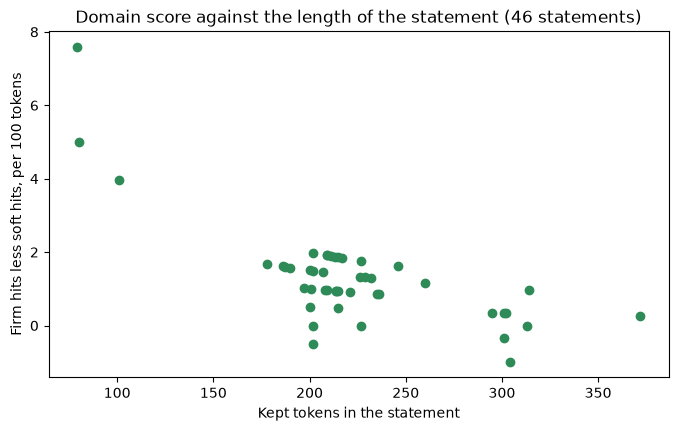

In [8]:
def domain_score(tokens):
    return list_score(tokens, firm_words, soft_words)


statements['domain'] = statements['kept'].apply(domain_score)

# the correlation of two columns
ex4_corr = round(statements['n_kept'].corr(statements['domain']), 2)

# z-scores of the token counts
z_length = (statements['n_kept'] - statements['n_kept'].mean()) / statements['n_kept'].std()
ex4_z = round(z_length.min(), 2)

print('Correlation of tokens kept with the domain score:', ex4_corr)
print('z-score of the shortest statement:', ex4_z)

# the same correlation without the three shortest statements
longer = statements[statements['n_kept'] > 101]
print('Without the three shortest:', len(longer), 'statements, correlation',
      round(longer['n_kept'].corr(longer['domain']), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(statements['n_kept'], statements['domain'], color='seagreen')
ax.set_title('Domain score against the length of the statement (46 statements)')
ax.set_xlabel('Kept tokens in the statement')
ax.set_ylabel('Firm hits less soft hits, per 100 tokens')
plt.show()

* The correlation between the number of kept tokens and the domain score is -0.75. Across this file, the shorter the statement, the higher the score.
* The shortest statement, with 79 tokens, is 2.57 standard deviations below the mean length.
* The chart shows three points far to the left and high up, apart from the other 43. Without those three the correlation is -0.55.
* A score per 100 tokens was meant to take length out of the comparison. In this file it has not. Keep the count beside every average.

In [9]:
check('Exercise 4 correlation', ex4_corr, -0.75)
check('Exercise 4 z-score of the shortest', ex4_z, -2.57)

Exercise 4 correlation: correct
Exercise 4 z-score of the shortest: correct


### Exercise 5

Q. The first habit of the lesson is to print the words that hit. Write a function `hit_counts(tokens, word_list)` that **returns** a dictionary: each word of `word_list` that appears in `tokens`, with the number of times it appears. A word with no hits is left out. The check cell calls your function on a short typed list and on the kept tokens of the statement dated 2024-03-20.

In [10]:
def hit_counts(tokens, word_list):
    """Return a dictionary: each word of word_list found in tokens, with the number of times it appears."""
    counts = {}
    for token in tokens:
        if token in word_list:
            # get() gives the count so far, or 0 the first time the word is seen
            counts[token] = counts.get(token, 0) + 1
    return counts


# a check that matters is an assert, on a list short enough to count by eye
assert hit_counts(['inflation', 'rate', 'inflation'], ['inflation']) == {'inflation': 2}, 'the count on the typed list is wrong'

# the negative hits of one statement, word by word
tokens = statements.loc[statements['date'] == '2024-03-20', 'kept'].iloc[0]
hits = hit_counts(tokens, negative_words)
print(hits)
print(f'Statement dated 2024-03-20: {sum(hits.values()):,} negative hits on {len(tokens):,} tokens')

# the same function on the tokens of all 46 statements, joined into one list
all_tokens = []
for kept in statements['kept']:
    all_tokens.extend(kept)

all_hits = hit_counts(all_tokens, negative_words)
print(all_hits)
print(f'All statements: {sum(all_hits.values()):,} negative hits on {len(all_tokens):,} tokens, and inflation is {all_hits["inflation"]:,} of them')

{'unemployment': 1, 'inflation': 8, 'risks': 4, 'uncertain': 1, 'debt': 1, 'pressures': 1}
Statement dated 2024-03-20: 16 negative hits on 202 tokens
{'hardship': 11, 'inflation': 324, 'risks': 121, 'pressures': 50, 'weak': 3, 'unemployment': 40, 'uncertain': 19, 'debt': 31, 'restrictive': 4, 'decline': 3, 'lower': 14}
All statements: 620 negative hits on 10,204 tokens, and inflation is 324 of them


* For the statement dated 2024-03-20 the function returns `inflation` 8, `risks` 4, and `unemployment`, `uncertain`, `debt`, and `pressures` once each: 16 negative hits on 202 tokens, the count of exercise 1.
* Across the 46 statements the negative list has 620 hits on 10,204 tokens, and `inflation` is 324 of them.
* The function returns its answer, so the check cell can call it on any tokens and any list. The `assert` tests it on three tokens that can be counted by eye.
* These are counts of words from a stated list. They say which words produced a score, and nothing about what a statement means.
* In Excel, with the 202 kept tokens of the statement in B2:B203, `=COUNTIF(B2:B203, "inflation")` returns 8.

In [11]:
# the kept tokens of the statement dated 2024-03-20
tokens_0320 = statements.loc[statements['date'] == '2024-03-20', 'kept'].iloc[0]

check('Exercise 5 typed list', hit_counts(['inflation', 'rate', 'inflation', 'gains', 'risks'], ['inflation', 'risks']), {'inflation': 2, 'risks': 1})
check('Exercise 5 negative hits of 2024-03-20', hit_counts(tokens_0320, negative_words),
      {'inflation': 8, 'risks': 4, 'unemployment': 1, 'uncertain': 1, 'debt': 1, 'pressures': 1})

Exercise 5 typed list: correct
Exercise 5 negative hits of 2024-03-20: correct


### Exercise 6: AI check

You ask an AI assistant for the VADER score of the statement dated 2025-06-18, and for the number of statements that VADER scores below zero. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. The lesson worked out both numbers in sections 4.2 and 4.3: 0.802 and 12. Then run the code. Does the answer agree with the lesson?

* The lesson's numbers are 0.802 for the statement dated 2025-06-18 and 12 statements below zero. The original code reported 0.4404 and 11, with no error.
* The bug was the line that cleaned the text before scoring it. Cleaning and stopword removal are right for a token count, and the assistant applied them out of habit. VADER's rules use what cleaning removes: `not`, `but`, punctuation, and capital letters. Section 4.2 showed 41 of 46 scores changing.
* The two answers were wrong by different amounts. The score was off by 0.36, which is hard to miss. The count was 11 against 12, a gap small enough to be passed over. Check against the number, not against roughly the number.
* The fix is to score the text as published.

In [12]:
# VADER takes the raw text, with no cleaning
statements['vader'] = statements['text'].apply(vader_score)

ex6_score = round(statements.loc[statements['date'] == '2025-06-18', 'vader'].iloc[0], 4)
ex6_below = int((statements['vader'] < 0).sum())

print('VADER score of the statement dated 2025-06-18:', ex6_score)
print('Statements scored below zero:', ex6_below)

VADER score of the statement dated 2025-06-18: 0.802
Statements scored below zero: 12


In [13]:
check('Exercise 6 score of 2025-06-18', ex6_score, 0.802)
check('Exercise 6 statements below zero', ex6_below, 12)

Exercise 6 score of 2025-06-18: correct
Exercise 6 statements below zero: correct
